# SVD
* 특이값 분해
* PCA : 정방행렬만을 고유벡터로 분해 <-> SVD : 행과 열 크기 다른 행렬도 가능
* m X n 크기의 행렬A을 다음과 같이 분해함
  * 특이 벡터(singular vector) : 행렬 U, V에 속한 벡터. 모든 특이 벡터는 서로 직교함
  * Σ : 대각 행렬 -> 대각에 위치한 값만 0이 아니고, 나머지는 모두 0
  * 행렬 A의 특이값 : Σ이 위치한 0이 아닌 값
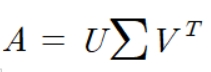
* A의 차원이 m X n일 때, U의 차원이 mXm, Σ의 차원이 mXn, V.T의 차원이 nXn으로 분해됨
* 일반적으로 Σ의 비대각부분과 대각원소 중 특이값이 0인 부분도 모두 제거하고, 제거된 Σ에 대응되는 U, V 원소도 함께 제거해 차원 줄여 SVD 적용(컴팩트!)
  * A(mxn), U(mxp), Σ(pxp), V.t(pxn)
  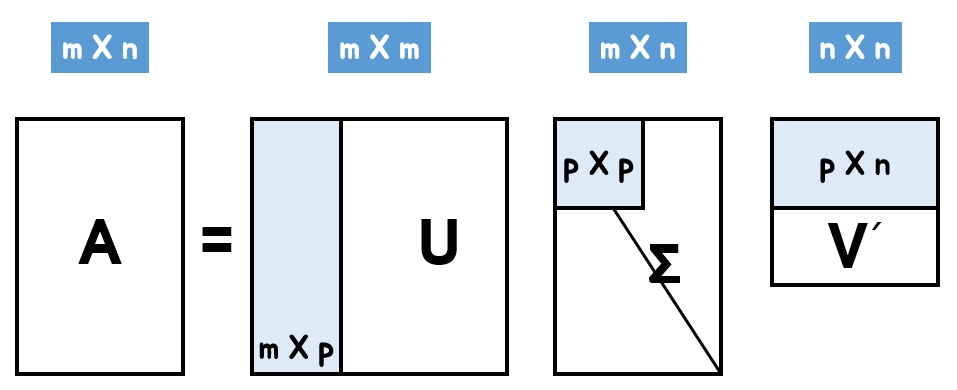
* Truncated SVD : Σ의 대각원소 중에 상위 몇 개만 추출해서 여기에 대응하는 U, V의 원소도 함께 제거해 더욱 차원 줄인 형태로 분해하는 것
* 보통 넘파이/사이파이 라이브러리 이용해 SVD 수행

# SVD 실습

In [5]:
###라이브러리 로딩

import numpy as np
from numpy.linalg import svd
from scipy.sparse.linalg import svds
from scipy.linalg import svd

In [2]:
### 
#랜덤 행렬 생성. 랜덤으로 뽑는 건 행렬 개별 로우끼리 의존성 없애기 위해서임
np.random.seed(121)
a = np.random.randn(4, 4)
print(np.round(a, 3))

#SVD분해 적용해 각 행렬 도출
U, Sigma, Vt = svd(a)
print(U.shape, Sigma.shape, Vt.shape)
print('U matrix :\n', np.round(U, 3))
print('Sigma Value : \n', np.round(Sigma, 3))
print('V transpose matrix : \n', np.round(Vt, 3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.014  0.63   1.71  -1.327]
 [ 0.402 -0.191  1.404 -1.969]]
(4, 4) (4,) (4, 4)
U matrix :
 [[-0.079 -0.318  0.867  0.376]
 [ 0.383  0.787  0.12   0.469]
 [ 0.656  0.022  0.357 -0.664]
 [ 0.645 -0.529 -0.328  0.444]]
Sigma Value : 
 [3.423 2.023 0.463 0.079]
V transpose matrix : 
 [[ 0.041  0.224  0.786 -0.574]
 [-0.2    0.562  0.37   0.712]
 [-0.778  0.395 -0.333 -0.357]
 [-0.593 -0.692  0.366  0.189]]


In [3]:
###데이터셋이 로우 간 의존성 있을 때 Sigma 값과 차원축소 알아보기
#의존성 부여하기 위해 행렬 조작
a[2] = a[0] + a[1]
a[3] = a[0]
#SVD분해 적용해 각 행렬 도출
U, Sigma, Vt = svd(a)
print(U.shape, Sigma.shape, Vt.shape)
print('Sigma Value : \n', np.round(Sigma, 3))

(4, 4) (4,) (4, 4)
Sigma Value : 
 [2.663 0.807 0.    0.   ]


* 이전과 차원은 같지만 시그마값 중 2개가 0이 됨
* 즉, 선형 독립인 로우 벡터 개수가 2개임

# Truncated SVD 실습
* 인위적으로 더 작은 차원의 U, Sigma, V.T로 분해됨 -> 원본 행렬 복원 불가
* 데이터 정보 압축되어 분해되어도, 상당 수준으로 원본 행렬 근사 가능
* cf : 원래 차원의 차수에 가깝게 잘라낼수록(truncate) 원본 행렬에 더 가깝게 복원 가능
* 넘파이 아닌 사이파이에서만 지원됨, 희소행렬로만

In [6]:
#원본 행렬
np.random.seed(121)
matrix = np.random.random((6, 6))
print('원본 행렬 : \n', matrix)

#SVD분해 적용해 각 행렬 도출
U, Sigma, Vt = svd(matrix, full_matrices=False)
print(U.shape, Sigma.shape, Vt.shape)
print('Sigma Value : \n', np.round(Sigma, 3))

#truncated svd
num_components = 4 #특잇값 개수
U_tr, Sigma_tr, Vt_tr = svds(matrix, k=num_components)
print(U_tr.shape, Sigma_tr.shape, Vt_tr.shape)
print('Sigma Value : \n', np.round(Sigma, 3))
matrix_tr = np.dot(np.dot(U_tr, np.diag(Sigma_tr)), Vt_tr)
print('Truncated SVD로 분해 후 복원 행렬 : \n', matrix_tr)

원본 행렬 : 
 [[0.11133083 0.21076757 0.23296249 0.15194456 0.83017814 0.40791941]
 [0.5557906  0.74552394 0.24849976 0.9686594  0.95268418 0.48984885]
 [0.01829731 0.85760612 0.40493829 0.62247394 0.29537149 0.92958852]
 [0.4056155  0.56730065 0.24575605 0.22573721 0.03827786 0.58098021]
 [0.82925331 0.77326256 0.94693849 0.73632338 0.67328275 0.74517176]
 [0.51161442 0.46920965 0.6439515  0.82081228 0.14548493 0.01806415]]
(6, 6) (6,) (6, 6)
Sigma Value : 
 [3.254 0.881 0.839 0.555 0.358 0.035]
(6, 4) (4,) (4, 6)
Sigma Value : 
 [3.254 0.881 0.839 0.555 0.358 0.035]
Truncated SVD로 분해 후 복원 행렬 : 
 [[0.19222941 0.21792946 0.15951023 0.14084013 0.81641405 0.42533093]
 [0.44874275 0.72204422 0.34594106 0.99148577 0.96866325 0.4754868 ]
 [0.12656662 0.88860729 0.30625735 0.59517439 0.28036734 0.93961948]
 [0.23989012 0.51026588 0.39697353 0.27308905 0.05971563 0.57156395]
 [0.83806144 0.78847467 0.93868685 0.72673231 0.6740867  0.73812389]
 [0.59726589 0.47953891 0.56613544 0.80746028 0.131350

# 사이킷런 TruncatedSVD 클래스를 이용한 변환
* 사이파이 svds처럼 원본행렬을 분해한 행렬들을 반환하진 않음
* fit, transfrom 호출해 원본 데이터를 몇 개의 주요 컴포넌트(truncated SVD의 K 컴포넌트 수)로 차원 축소해 변환함
* 원본 데이터를 Trucated SVD 방ㅅ기으로 분해된 U * Sigma 행렬에 선형 변환해 생성
* 사이킷런의 TruncatedSVD, PCA 클래스 모두 SVD를 이용해 행렬 분해함

In [9]:
###라이브러리 로드
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'TruncatedSVD Component 2')

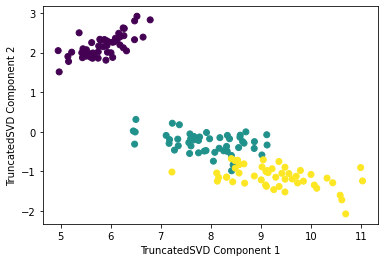

In [8]:
iris = load_iris()
iris_features = iris.data
#2개의 주요 컴포넌트로 TruncatedSVD 변환
tsvd=TruncatedSVD(n_components=2)
tsvd.fit(iris_features)
iris_tsvd = tsvd.transform(iris_features)

#산점도 2차원으로 변환된 데이터 표현
plt.scatter(x=iris_tsvd[:, 0], y=iris_tsvd[:, 1], c=iris.target)
plt.xlabel('TruncatedSVD Component 1')
plt.ylabel('TruncatedSVD Component 2')

Text(0.5, 1.0, 'PCA Transformed')

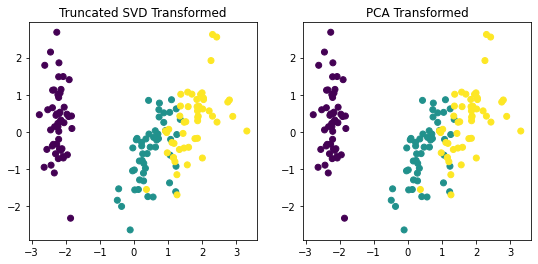

In [10]:
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_features)

tsvd=TruncatedSVD(n_components=2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)

pca = PCA(n_components=2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

fig, (ax1, ax2) = plt.subplots(figsize=(9, 4), ncols=2)
ax1.scatter(x=iris_tsvd[:, 0], y=iris_tsvd[:, 1], c=iris.target)
ax2.scatter(x=iris_pca[:, 0], y=iris_pca[:, 1], c=iris.target)
ax1.set_title('Truncated SVD Transformed')
ax2.set_title('PCA Transformed')

In [11]:
print((iris_pca-iris_tsvd).mean())
print((pca.components_ - tsvd.components_).mean())

2.332185370749566e-15
-8.803721640582296e-17


* 모두 0에 가까운 값 -> 2개의 변환이 서로 동일 -> 데이터셋이 스케일링으로 데이터 중심이 동일해지면, 사이킷런의 SVD와 PCA는 동일한 변환 수행함 -> PCA가 SVD 알고리즘으로 구현되었음
* PCA는 밀집 행렬(Dense Matrix)에 대한 변환만 가능
* SVD는 희소 행렬(Sparse Matrix)에 대한 변환도 가능
* SVD는 컴퓨터비전에서 이미지 압축 통한 패턴 인식, 신호 처리 분야에 사용됨 / 텍스트 토픽 모델링 기법 LSA(Latent Semantic Analysis) 기반 알고리즘임